In [1]:
import pandas as pd


listening = pd.read_csv('listening_history.csv')
artists = pd.read_csv('artists.csv')
tags = pd.read_csv('tags.csv')
artist_tags = pd.read_csv('artist_tags.csv')


In [2]:
artists.head()

,id,name,url,pictureURL
0,1,MALICE MIZER,http://www.last.fm/music/MALICE+MIZER,http://userserve-ak.last.fm/serve/252/10808.jpg
1,2,Diary of Dreams,http://www.last.fm/music/Diary+of+Dreams,http://userserve-ak.last.fm/serve/252/3052066.jpg
2,3,Carpathian Forest,http://www.last.fm/music/Carpathian+Forest,http://userserve-ak.last.fm/serve/252/40222717...
3,4,Moi dix Mois,http://www.last.fm/music/Moi+dix+Mois,http://userserve-ak.last.fm/serve/252/54697835...
4,5,Bella Morte,http://www.last.fm/music/Bella+Morte,http://userserve-ak.last.fm/serve/252/14789013...


In [3]:
artist_tags.head()

,userID,artistID,tagID,day,month,year
0,2,52,13,1,4,2009
1,2,52,15,1,4,2009
2,2,52,18,1,4,2009
3,2,52,21,1,4,2009
4,2,52,41,1,4,2009


In [4]:
tags.head()

,tagID,tagValue
0,1,metal
1,2,alternative metal
2,3,goth rock
3,4,black metal
4,5,death metal


In [5]:
listening.head()

,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


In [6]:


data = pd.merge(listening, artist_tags ,on='artistID')




In [7]:
data.head()     

,userID_x,artistID,weight,userID_y,tagID,day,month,year
0,2,51,13883,4,16,1,12,2007
1,2,51,13883,4,25,1,3,2007
2,2,51,13883,43,16,1,10,2010
3,2,51,13883,43,25,1,10,2010
4,2,51,13883,62,16,1,11,2009


In [8]:
data.drop(columns=['weight'], inplace=True)

In [9]:
data.head()

,userID_x,artistID,userID_y,tagID,day,month,year
0,2,51,4,16,1,12,2007
1,2,51,4,25,1,3,2007
2,2,51,43,16,1,10,2010
3,2,51,43,25,1,10,2010
4,2,51,62,16,1,11,2009


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [11]:
print("Total listeners:", len(data))
print("Total users:", data["tagID"].nunique())
print("Total artists:", data["artistID"].nunique())

Total listeners: 10942617
Total users: 9718
Total artists: 12133


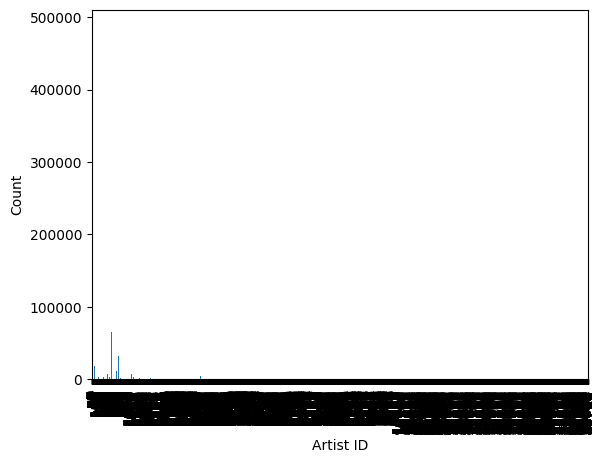

In [12]:
data["artistID"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Artist ID")
plt.ylabel("Count")
plt.show()

In [13]:
user_listener = data.groupby("tagID")["artistID"].count()

user_listener.describe()

count      9718.000000
mean       1126.015332
std       13055.756058
min           1.000000
25%           3.000000
50%          38.000000
75%         258.000000
max      628982.000000
Name: artistID, dtype: float64

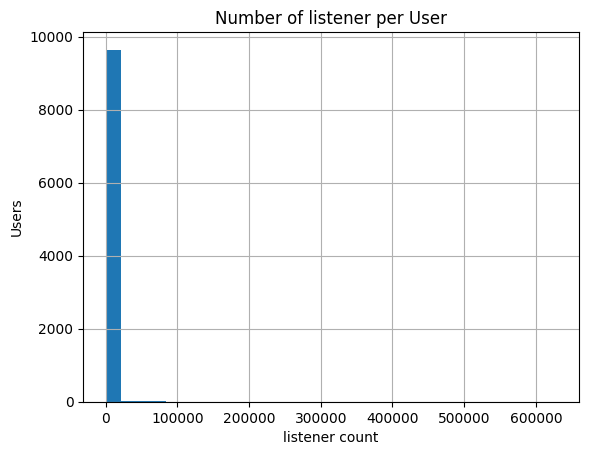

In [14]:
user_listener.hist(bins=30)
plt.title("Number of listener per User")
plt.xlabel("listener count")
plt.ylabel("Users")
plt.show()

In [15]:
n_users = data["tagID"].nunique()
n_songs = data["artistID"].nunique()
n_listeners = len(data)

sparsity = 1 - (n_listeners / (n_users * n_songs))
print(f"Sparsity of matrix: {sparsity*100:.2f}%")

Sparsity of matrix: 90.72%


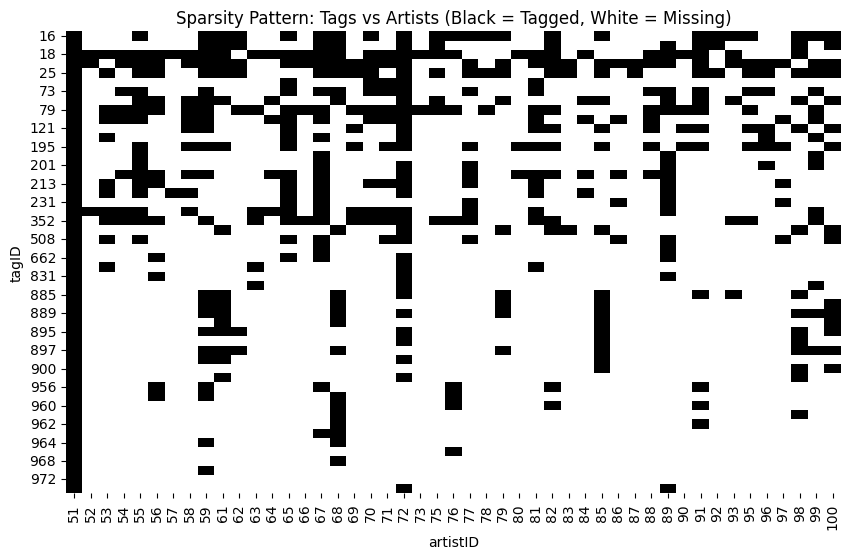

In [16]:

sample_tags = data["tagID"].unique()[:50]
sample_artists = data["artistID"].unique()[:50]


filtered_sample = data[
    (data["tagID"].isin(sample_tags)) & 
    (data["artistID"].isin(sample_artists))
]


sample_matrix = filtered_sample.pivot_table(
    index="tagID", 
    columns="artistID", 
    values="userID_x", 
    aggfunc='count' 
)


plt.figure(figsize=(10,6))
sns.heatmap(sample_matrix.notna(), cbar=False, cmap="Greys")
plt.title("Sparsity Pattern: Tags vs Artists (Black = Tagged, White = Missing)")
plt.show()

In [17]:
song_stats = data.groupby("artistID").agg({
    "tagID": ["mean", "count"]
})

song_stats.columns = ["avg_listening", "listening_count"]
song_stats.sort_values("listening_count", ascending=False).head(10)

,avg_listening,listening_count
artistID,,
289,1488.068743,485982
89,1505.344198,468637
67,1176.972603,313170
292,1446.337270,310134
227,1131.516722,287040
288,1277.253788,255552
190,1006.304202,238000
154,993.083481,221259
300,1263.082547,200552


In [18]:

user_song_matrix = data.pivot_table(
    index="artistID",
    columns="tagID",
    values="userID_x",
    aggfunc='count'
)

user_song_matrix = user_song_matrix.fillna(0)

print("\nUser–Song Matrix (Sample View)")
print(user_song_matrix.iloc[:5, :10])


User–Song Matrix (Sample View)
tagID      1    2    3    4    5    6    7    8    9    10
artistID                                                  
1         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
2         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
3         0.0  0.0  0.0  9.0  0.0  0.0  0.0  0.0  0.0  0.0
4         4.0  0.0  0.0  0.0  0.0  0.0  2.0  0.0  0.0  0.0
5         0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0


In [19]:
user_song_matrix_filled = user_song_matrix.fillna(0)

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_song_matrix_filled)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_song_matrix.index,
    columns=user_song_matrix.index
)


In [21]:
def recommend_songs(user_id, n_recommendations=5, k=10):
    
    if user_id not in user_similarity_df.index:
        return f"User {user_id} not found."

   
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)
    similar_users = similar_users.drop(user_id).head(k)


    user_interactions = user_song_matrix_filled.loc[user_id]
    already_interacted = user_interactions[user_interactions > 0].index

  
    weighted_scores = pd.Series(0, index=user_song_matrix_filled.columns)
    similarity_sum = similar_users.sum()

    for other_user, similarity_score in similar_users.items():
        other_user_ratings = user_song_matrix_filled.loc[other_user]
        weighted_scores += similarity_score * other_user_ratings

    if similarity_sum > 0:
        weighted_scores = weighted_scores / similarity_sum
    

    
    weighted_scores = weighted_scores.drop(already_interacted, errors='ignore')

 
    recommended_ids = weighted_scores.sort_values(ascending=False).head(n_recommendations).index

 
    recommendations = artists[artists["id"].isin(recommended_ids)][["id", "name"]]
    return recommendations

In [22]:

recommend_songs(user_id=2, n_recommendations=10)

,id,name
6,7,Marilyn Manson
22,24,Feindflug
68,74,Basia
80,86,Katie Melua
556,562,The Who
560,566,Jackie Wilson
594,600,le bowl
841,850,Haste the Day
1469,1478,B.J. Thomas
9511,9745,Etienne Daho
